Columns Loaded:
 Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'customer_value', 'loyal_customer',
       'estimated_revenue'],
      dtype='str')

Shipping Performance Summary:

    shipping_type  customer_count  average_spend  estimated_revenue  rank
1         Express             931      62.460806           58151.01     1
4        Standard             920      60.737348           55878.36     2
2   Free Shipping             675      60.410370           40777.00     3
5    Store Pickup             650      59.893846           38931.00     4
0  2-Day Shipping             627      60.733652           38080.00     5
3    Next Day Air             648      58.631173           37993.00     6


C:\Users\prasa\AppData\Local\Temp\ipykernel_30508\3032581445.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="shipping_type", palette="Blues", ax=axes[0, 0])
C:\Users\prasa\AppData\Local\Temp\ipykernel_30508\3032581445.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\prasa\AppData\Local\Temp\ipykernel_30508\3032581445.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


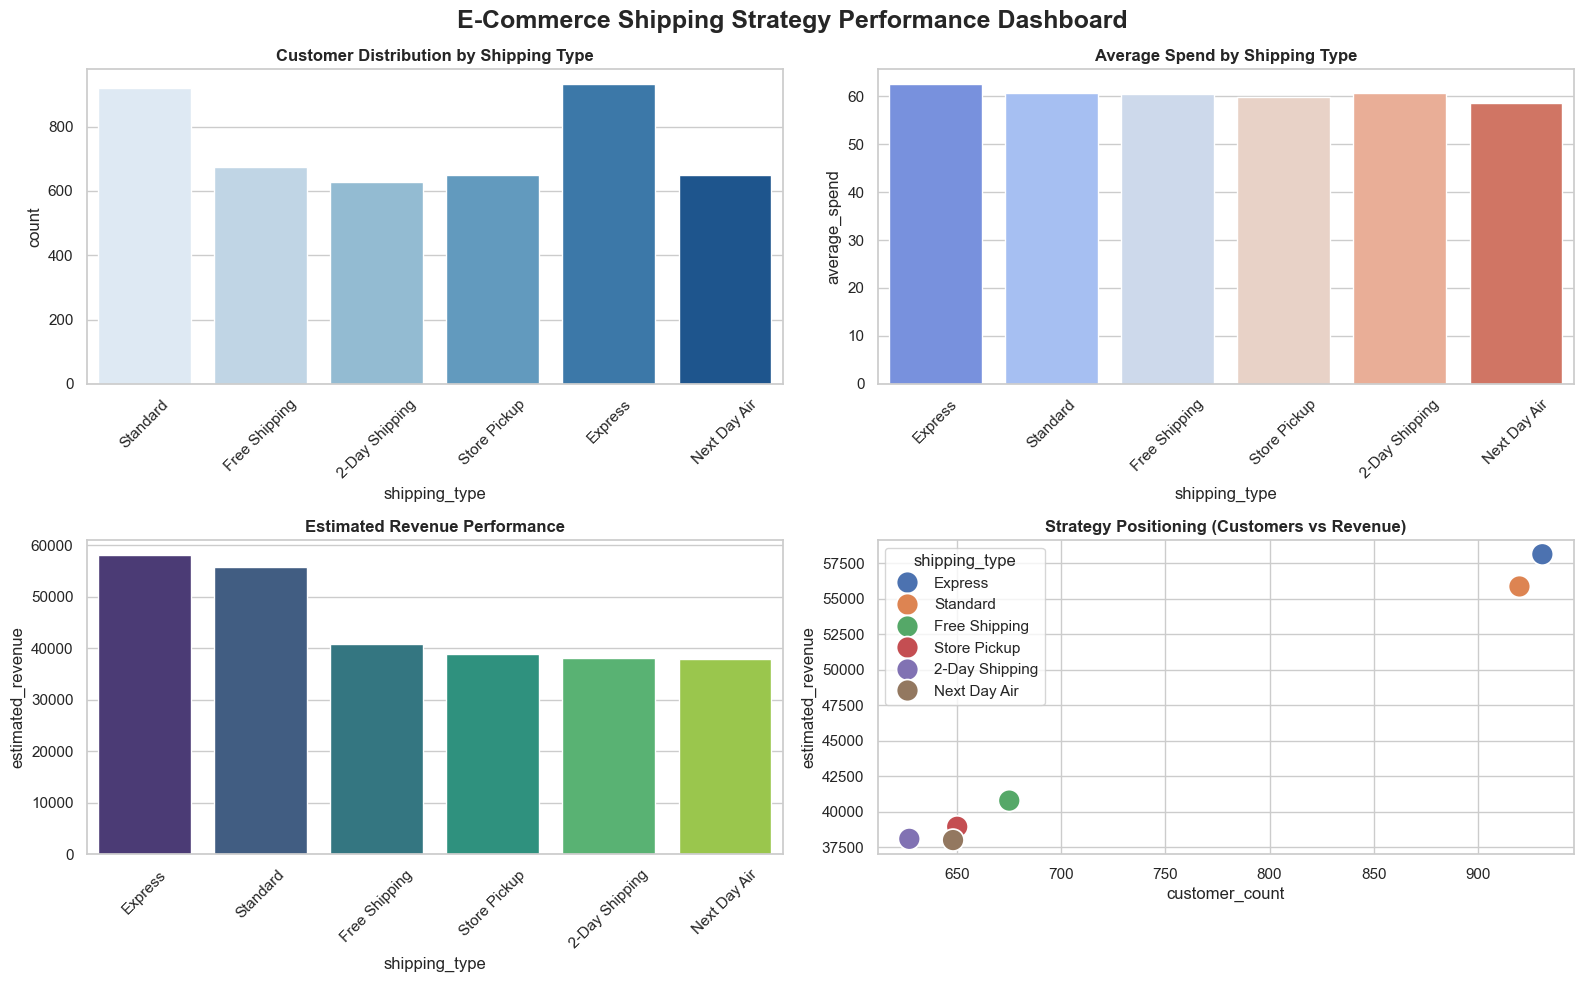

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("cleaned_customer_shopping_behavior.csv")


df.columns = (
    df.columns.str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print("Columns Loaded:\n", df.columns)


shipping_summary = (
    df.groupby("shipping_type")
    .agg(
        customer_count=("shipping_type", "count"),
        average_spend=("purchase_amount_usd", "mean"),
    )
    .reset_index()
)


# CREATE ESTIMATED REVENUE

shipping_summary["estimated_revenue"] = (
    shipping_summary["customer_count"] * shipping_summary["average_spend"]
)


#  RANK SHIPPING METHODS

shipping_summary = shipping_summary.sort_values(by="estimated_revenue", ascending=False)

shipping_summary["rank"] = range(1, len(shipping_summary) + 1)

print("\nShipping Performance Summary:\n")
print(shipping_summary)


#  FINAL EXECUTIVE DASHBOARD


sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Chart 1 — Customer Distribution

sns.countplot(data=df, x="shipping_type", palette="Blues", ax=axes[0, 0])

axes[0, 0].set_title("Customer Distribution by Shipping Type", weight="bold")
axes[0, 0].tick_params(axis="x", rotation=45)


# Chart 2 — Average Spend

sns.barplot(
    data=shipping_summary,
    x="shipping_type",
    y="average_spend",
    palette="coolwarm",
    ax=axes[0, 1],
)

axes[0, 1].set_title("Average Spend by Shipping Type", weight="bold")
axes[0, 1].tick_params(axis="x", rotation=45)


# Chart 3 — Estimated Revenue

sns.barplot(
    data=shipping_summary,
    x="shipping_type",
    y="estimated_revenue",
    palette="viridis",
    ax=axes[1, 0],
)

axes[1, 0].set_title("Estimated Revenue Performance", weight="bold")
axes[1, 0].tick_params(axis="x", rotation=45)


# Chart 4 — Strategic Positioning

sns.scatterplot(
    data=shipping_summary,
    x="customer_count",
    y="estimated_revenue",
    hue="shipping_type",
    s=250,
    ax=axes[1, 1],
)

axes[1, 1].set_title("Strategy Positioning (Customers vs Revenue)", weight="bold")


# Dashboard Title

plt.suptitle(
    "E-Commerce Shipping Strategy Performance Dashboard", fontsize=18, weight="bold"
)

plt.tight_layout()

# Save dashboard
plt.savefig("shipping_strategy_dashboard.png", dpi=300)

plt.show()